## Implementacja sieci Kohonena - wczytanie danych

In [26]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [15]:
df_hex = pd.read_csv('kohonen_data/hexagon.csv')
df_cube = pd.read_csv('kohonen_data/cube.csv')

In [4]:
X_treningowe = df_hex[['x', 'y']].values

In [12]:
etykiety_klas_hex = df_hex['c'].values

In [10]:
scaler = MinMaxScaler()
X_gotowe_hex = scaler.fit_transform(X_treningowe)

In [11]:
X_gotowe_hex[:5]

array([[0.74968175, 0.73488462],
       [0.4200263 , 0.93217116],
       [0.72823557, 0.37087037],
       [0.83334619, 0.66741976],
       [0.83271504, 0.38523445]])

In [16]:
X_treningowe = df_cube[['x', 'y', 'z']].values

In [17]:
etykiety_klas_cube = df_hex['c'].values

In [18]:
scaler = MinMaxScaler()
X_gotowe_cube = scaler.fit_transform(X_treningowe)

In [19]:
X_gotowe_cube[:5]

array([[0.31133808, 0.29995395, 0.38199276],
       [0.09697057, 0.25404951, 0.12459394],
       [0.14299692, 0.3527554 , 0.30185374],
       [0.41692037, 0.34404072, 0.2809998 ],
       [0.27031328, 0.27175274, 0.19666808]])

## Imlementacja sieci Kohonena

### Inicjalizacja architektury

In [29]:
class KohonenNetwork:
    def __init__(self, m, n):
        self.m = m
        self.n = n
        self.weights = None
        x_coords, y_coords = np.meshgrid(np.arange(m), np.arange(n), indexing='ij')
        self.grid_coords = np.stack([x_coords, y_coords], axis=-1)
        
    def _initialize_weights(self, num_features):
        """
        Inicjalizuje wagi neuronów losowymi wartościami z przedziału [0, 1].
        Wywoływane automatycznie przy pierwszym uruchomieniu uczenia.
        """
        self.weights = np.random.rand(self.m, self.n, num_features)
        print(f"Zainicjalizowano wagi o wymiarach: {self.weights.shape}")
    def _learning_rate(self, t, lambda_param):
        """
        Współczynnik uczenia wygasający w czasie.
        t: aktualna iteracja/epoka
        lambda_param: stała kontrolująca tempo spadku (np. max_epok / 2)
        """
        return np.exp(-t / lambda_param)

    def _neighborhood_gaussian(self, x, c):
        """
        Funkcja sąsiedztwa 1: Gaussowska.
        x: macierz odległości topologicznych wszystkich neuronów od BMU
        c: parametr szerokości sąsiedztwa
        """
        return np.exp(-(c * x)**2)

    def _neighborhood_mexican_hat(self, x, c):
        """
        Funkcja sąsiedztwa 2: Minus druga pochodna Gaussa (Meksykański Kapelusz).
        x: macierz odległości topologicznych wszystkich neuronów od BMU
        c: parametr szerokości sąsiedztwa
        """
        cx_sq = (c * x)**2 
        return (1 - cx_sq) * np.exp(-cx_sq / 2)
    def fit(self, X, epochs=100, neighborhood_func='gaussian', c=1.0):
        """
        Główna pętla ucząca sieć Kohonena.
        X: zbiór danych treningowych (np. X_gotowe_hex lub X_gotowe_cube)
        epochs: liczba iteracji
        neighborhood_func: 'gaussian' lub 'mexican_hat'
        c: parametr szerokości sąsiedztwa
        """
        num_samples, num_features = X.shape
        if self.weights is None:
            self._initialize_weights(num_features)
        lambda_param = epochs / 2.0
        if neighborhood_func == 'gaussian':
            calc_neighborhood = self._neighborhood_gaussian
        elif neighborhood_func == 'mexican_hat':
            calc_neighborhood = self._neighborhood_mexican_hat
        else:
            raise ValueError("Wybierz 'gaussian' lub 'mexican_hat'")
        for epoch in range(epochs):
            alpha_t = self._learning_rate(epoch, lambda_param)
            indices = np.random.permutation(num_samples)
            X_shuffled = X[indices]
            for v in X_shuffled:
                distances_to_v = np.linalg.norm(self.weights - v, axis=-1)
                bmu_idx = np.unravel_index(np.argmin(distances_to_v), (self.m, self.n))
                bmu_coords = np.array(bmu_idx)
                topological_distances = np.linalg.norm(self.grid_coords - bmu_coords, axis=-1)
                influence = calc_neighborhood(topological_distances, c)
                influence_expanded = influence[:, :, np.newaxis]
                self.weights += alpha_t * influence_expanded * (v - self.weights)
                
        print(f"Zakończono uczenie po {epochs} epokach.")

#### Test na zbiorze hexagon z wizualizacją wyników

In [ ]:
def plot_som_2d(X, weights, title="Siatka SOM nałożona na dane 2D"):
    plt.figure(figsize=(8, 8))
    plt.scatter(X[:, 0], X[:, 1], c='lightgray', label='Dane treningowe', alpha=0.6)
    m, n, _ = weights.shape
    for i in range(m):
        for j in range(n):
            if i < m - 1:
                plt.plot([weights[i, j, 0], weights[i+1, j, 0]], 
                         [weights[i, j, 1], weights[i+1, j, 1]], 'k-', alpha=0.3)
            if j < n - 1:
                plt.plot([weights[i, j, 0], weights[i, j+1, 0]], 
                         [weights[i, j, 1], weights[i, j+1, 1]], 'k-', alpha=0.3)
    weights_2d = weights.reshape(m * n, 2)
    plt.scatter(weights_2d[:, 0], weights_2d[:, 1], c='red', edgecolors='black', label='Neurony', zorder=3)
    
    plt.title(title)
    plt.legend()
    plt.show()

def evaluate_som_classes(model, X, labels):
    neuron_classes = defaultdict(list)
    
    for i, x in enumerate(X):
        distances = np.linalg.norm(model.weights - x, axis=-1)
        bmu_idx = tuple(np.unravel_index(np.argmin(distances), (model.m, model.n)))
        neuron_classes[bmu_idx].append(labels[i])
        
    return neuron_classes

Zainicjalizowano wagi o wymiarach: (10, 10, 2)
Zakończono uczenie po 50 epokach.


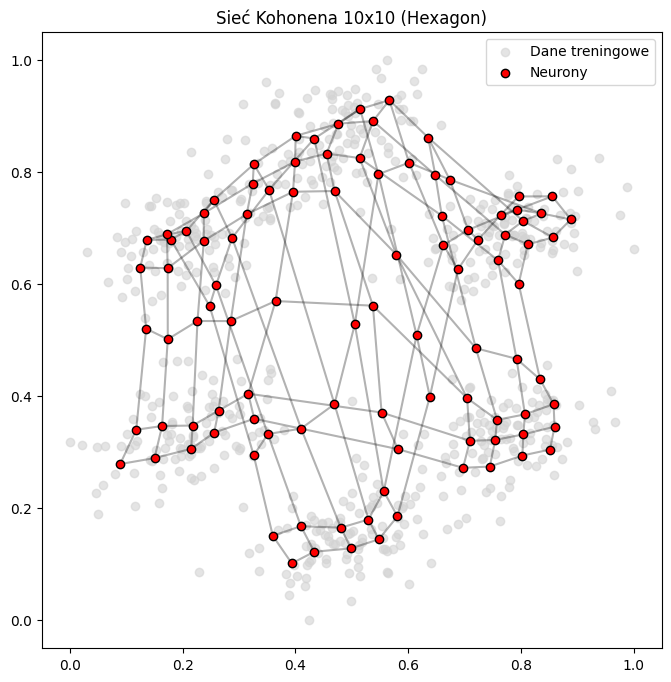

Liczba neuronów zawierających jakiekolwiek dane: 88 na 100

Analiza pierwszych 5 aktywnych neuronów:
Neuron na pozycji (np.int64(0), np.int64(8)):
  - Przypisanych elementów: 11
  - Występujące klasy: {np.int64(1)}
  - Czystość klasy dominującej: 100.00%
Neuron na pozycji (np.int64(4), np.int64(4)):
  - Przypisanych elementów: 8
  - Występujące klasy: {np.int64(0)}
  - Czystość klasy dominującej: 100.00%
Neuron na pozycji (np.int64(7), np.int64(7)):
  - Przypisanych elementów: 11
  - Występujące klasy: {np.int64(2)}
  - Czystość klasy dominującej: 100.00%
Neuron na pozycji (np.int64(4), np.int64(9)):
  - Przypisanych elementów: 7
  - Występujące klasy: {np.int64(1)}
  - Czystość klasy dominującej: 100.00%
Neuron na pozycji (np.int64(7), np.int64(9)):
  - Przypisanych elementów: 11
  - Występujące klasy: {np.int64(2)}
  - Czystość klasy dominującej: 100.00%


In [ ]:
som = KohonenNetwork(m=10, n=10)
som.fit(X_gotowe_hex, epochs=50, neighborhood_func='gaussian', c=1.0)
plot_som_2d(X_gotowe_hex, som.weights, title="Sieć Kohonena 10x10 (Hexagon)")
neuron_dict = evaluate_som_classes(som, X_gotowe_hex, etykiety_klas_hex)
aktywne_neurony = len(neuron_dict)
print(f"Liczba neuronów zawierających jakiekolwiek dane: {aktywne_neurony} na 100")
print("\nAnaliza pierwszych 5 aktywnych neuronów:")
for i, (coords, class_list) in enumerate(neuron_dict.items()):
    if i >= 5: break
    
    liczba_elementow = len(class_list)
    unikalne_klasy = set(class_list)
    czystosc = (class_list.count(list(unikalne_klasy)[0]) / liczba_elementow) * 100
    
    print(f"Neuron na pozycji {coords}:")
    print(f"  - Przypisanych elementów: {liczba_elementow}")
    print(f"  - Występujące klasy: {unikalne_klasy}")
    print(f"  - Czystość klasy dominującej: {czystosc:.2f}%")

#### TODO: U-matrix, nałożenie siatki na dane, słownik zawartości neuronów, aktywność neuronów